In [ ]:
import utils.paths as d
import utils.utils as u
import utils.functions as f
import numpy as np
import scanpy as sc
import spatialdata as sd
import spatialdata_plot
import zarr
import anndata as ad
import re
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.pyplot as plt
import os
import warnings
import pandas as pd
warnings.filterwarnings("ignore", category=UserWarning)

print("Python version:", __import__('sys').version)
for m in (sc, sd, spatialdata_plot, zarr, ad):
    print(f"{m.__name__} version: {m.__version__}")

c:\Users\sevco\Documents\diplomka\DiplomaThesis\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python version: 3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.1933 64 bit (AMD64)]
scanpy version: 1.11.5
spatialdata version: 0.7.3
spatialdata_plot version: 0.4.0
zarr version: 3.1.6
anndata version: 0.12.19


C:\Users\sevco\AppData\Local\Temp\ipykernel_14332\1622354573.py:17: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(f"{m.__name__} version: {m.__version__}")
C:\Users\sevco\AppData\Local\Temp\ipykernel_14332\1622354573.py:17: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  print(f"{m.__name__} version: {m.__version__}")


In [2]:
PARENT_DIR = d.project_root
PROSEG_DIR = d.proseg_dir
PROSEG_DIR = d.project_root / "data_raw" / "proseg_out_fixed_v2"
print("Parent directory:", PARENT_DIR)
print("Proseg directory:", PROSEG_DIR)

OUTPUT_DIR = d.preprocessed_dir
print("Output directory:", OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)


Parent directory: C:\Users\sevco\Documents\phd\proj_2026_Zimcik_Xenium\Xenium_Analysis_SATB2_UMG_2026
Proseg directory: C:\Users\sevco\Documents\phd\proj_2026_Zimcik_Xenium\Xenium_Analysis_SATB2_UMG_2026\data_raw\proseg_out_fixed_v2
Output directory: C:\Users\sevco\Documents\phd\proj_2026_Zimcik_Xenium\Xenium_Analysis_SATB2_UMG_2026\data\00_preprocess


In [3]:
samples_map = u.samples_map
samples_map

samples = ["C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8"]

In [4]:
wt_1 = sd.read_zarr(PROSEG_DIR / "C1" / "proseg-output.zarr")
wt_2 = sd.read_zarr(PROSEG_DIR / "C2" / "proseg-output.zarr")
wt_3 = sd.read_zarr(PROSEG_DIR / "C3" / "proseg-output.zarr")
wt_4 = sd.read_zarr(PROSEG_DIR / "C4" / "proseg-output.zarr")
mut_1 = sd.read_zarr(PROSEG_DIR / "C5" / "proseg-output.zarr")
mut_2 = sd.read_zarr(PROSEG_DIR / "C6" / "proseg-output.zarr")
mut_3 = sd.read_zarr(PROSEG_DIR / "C7" / "proseg-output.zarr")    
mut_4 = sd.read_zarr(PROSEG_DIR / "C8" / "proseg-output.zarr")

In [5]:
sdatas = {
    "C1": wt_1,  "C2": wt_2,  "C3": wt_3,  "C4": wt_4,
    "C5": mut_1, "C6": mut_2, "C7": mut_3, "C8": mut_4,
}

In [6]:
adata_wt_1 = wt_1.tables["table"]
adata_wt_2 = wt_2.tables["table"]
adata_wt_3 = wt_3.tables["table"]
adata_wt_4 = wt_4.tables["table"]

adata_wt =  ad.concat(
    [adata_wt_1, adata_wt_2, adata_wt_3, adata_wt_4],
    label="sample",
    keys=["wt_1", "wt_2", "wt_3", "wt_4"],
    index_unique=None,
)

adata_wt

AnnData object with n_obs × n_vars = 107010 × 4990
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'region', 'sample'
    obsm: 'spatial', 'metagene_rates'

In [8]:
# sc.pl.embedding(adata_wt, basis="spatial", color="sample", size=1.5)

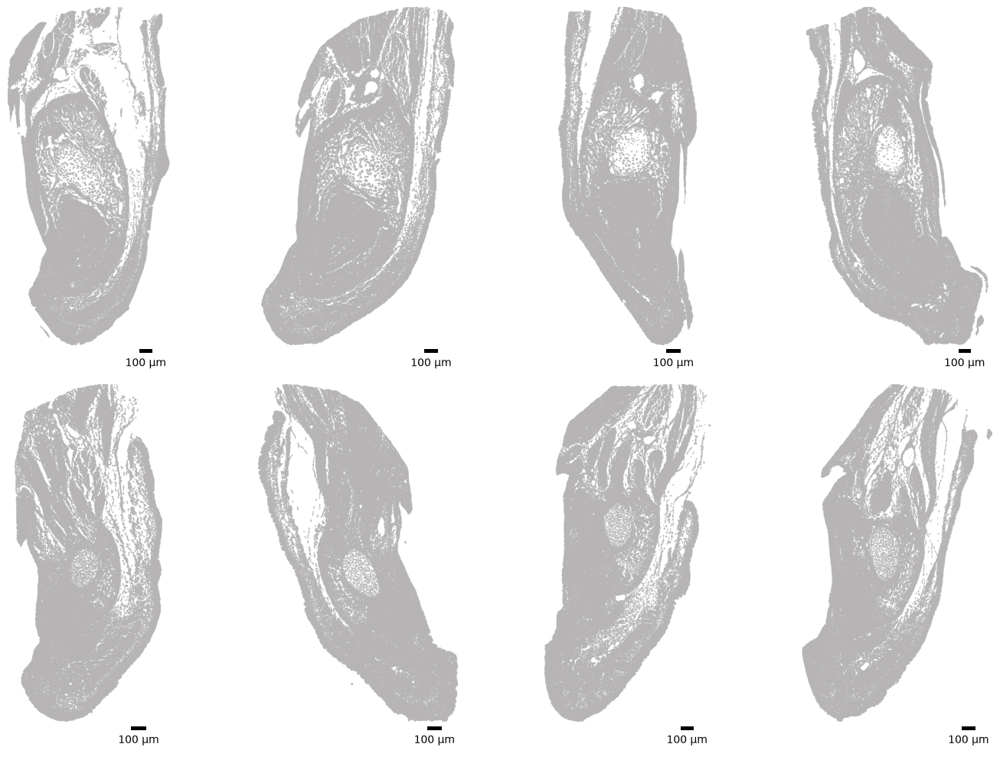

In [36]:
samples = sorted(sdatas.keys(), key=lambda s: (re.match(r"[A-Za-z]+", s).group(),
                                              int(re.search(r"\d+", s).group())))

fig, axes = plt.subplots(2, 4, figsize=(15, 10))
axes = axes.ravel()

for ax, s in zip(axes, samples):
    sdatas[s].pl.render_shapes('cell_boundaries', color="#B6B4B4").pl.show(ax=ax)
    if ax.get_legend():
        ax.get_legend().remove()
    ax.set_title("")

    # add 8% empty space at the visual bottom (works whether y is inverted or not)
    y0, y1 = ax.get_ylim()
    ax.set_ylim(y0 - 0.08 * (y1 - y0), y1)

    ax.add_artist(ScaleBar(
        dx=1, units="um", fixed_value=100, fixed_units="um",
        location="lower right", frameon=False,
    ))
    ax.set_axis_off()

plt.tight_layout()
plt.show()

In [40]:
adata_mut_1 = mut_1.tables["table"]
adata_mut_2 = mut_2.tables["table"]
adata_mut_3 = mut_3.tables["table"]
adata_mut_4 = mut_4.tables["table"]

adata_mut =  ad.concat(
    [adata_mut_1, adata_mut_2, adata_mut_3, adata_mut_4],
    label="sample",
    keys=["mut_1", "mut_2", "mut_3", "mut_4"],
    index_unique=None,
)

adata_mut

AnnData object with n_obs × n_vars = 98763 × 4992
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'region', 'sample'
    obsm: 'spatial'

In [ ]:
sdatas_wt  = {"wt_1": wt_1, "wt_2": wt_2, "wt_3": wt_3, "wt_4": wt_4}
sdatas_mut = {"mut_1": mut_1, "mut_2": mut_2, "mut_3": mut_3, "mut_4": mut_4}

qc_wt  = f.qc_table(adata_wt, sdatas_wt)
qc_mut = f.qc_table(adata_mut, sdatas_mut)

qc_all = pd.concat([qc_wt, qc_mut], keys=["WT", "MUT"], names=["condition", "sample"])
qc_all.to_csv(OUTPUT_DIR / "qc_summary_all.csv")

In [ ]:
adata_all = ad.concat(
    [adata_wt, adata_mut],
    label="condition",
    keys=["wt", "mut"],
    index_unique=None,
)

In [12]:
adata = f.adata_preprocessing(adata_all, min_cells=3, min_genes=100, target_sum=1e4, log1p=True,
                              scale_max_value=10, npcs=40, n_neighbors=20, min_dist=0.7, spread=0.9)

Using seurat_v3 flavor for HVG selection (counts layer found)


In [ ]:
sc.pp.neighbors(adata, n_neighbors=20, n_pcs=40)
sc.tl.umap(adata, min_dist=0.8, spread=0.9)


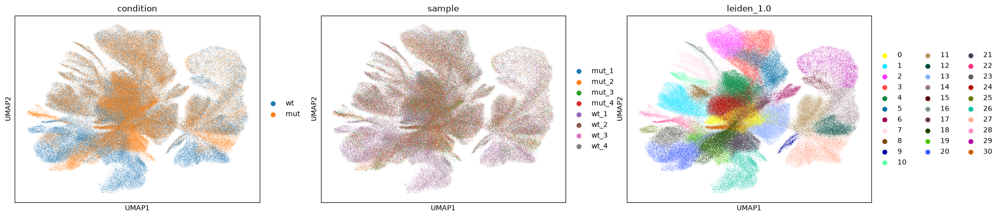

In [14]:
sc.pl.umap(adata, color=["condition", "sample", "leiden_1.0"], size=0.8)

In [ ]:
adata.write_h5ad(OUTPUT_DIR / "adata.h5ad")

In [ ]:
adata = sc.read_h5ad(OUTPUT_DIR / "adata.h5ad")

In [ ]:
adata_all = ad.concat(
    {sample: sdatas[sample].tables["table"] for sample in samples},
    label="sample",
    index_unique="_",
    join="inner",
)

adata_all.obs["condition"] = (
    adata_all.obs["sample"]
    .map({
        "C1": "wt", "C2": "wt", "C3": "wt", "C4": "wt",
        "C5": "mut", "C6": "mut", "C7": "mut", "C8": "mut",
    })
    .astype("category")
)

# Must happen before Pearson-residual normalization
sc.pp.filter_cells(adata_all, min_genes=100)
sc.pp.filter_genes(adata_all, min_cells=5)

In [15]:
sc.experimental.pp.recipe_pearson_residuals(
    adata_all,
    n_top_genes=2000,
    batch_key="sample",
    chunksize=1000,
    n_comps=40,
)
import numpy as np
assert np.isfinite(adata_all.obsm["X_pca"]).all()

sc.pp.neighbors(
    adata_all,
    n_neighbors=30,
    use_rep="X_pca",
)

sc.tl.umap(
    adata_all,
    min_dist=0.8,
    random_state=42,
)

c:\Users\sevco\Documents\diplomka\DiplomaThesis\venv\Lib\site-packages\scanpy\experimental\pp\_normalization.py:76: RuntimeWarning: invalid value encountered in divide
  residuals = diff / np.sqrt(mu + mu**2 / theta)


In [ ]:
sc.pl.umap(adata_all,color=["condition", "sample"],size=0.8)

In [ ]:
adata_all.write_h5ad(OUTPUT_DIR / "adata_pearson_res.h5ad")

# Annotation

In [5]:
adata = sc.read_h5ad(OUTPUT_DIR / "adata.h5ad")

In [6]:
adata

AnnData object with n_obs × n_vars = 200725 × 2000
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'region', 'sample', 'condition', 'n_genes', 'leiden_0.5', 'leiden_1.0', 'leiden_1.5', 'leiden_2.0'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'condition_colors', 'hvg', 'leiden_0.5', 'leiden_1.0', 'leiden_1.5', 'leiden_2.0', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts', 'lognorm'
    obsp: 'connectivities', 'distances'

In [7]:
mk = pd.DataFrame(u.data_markers)
markers = {r.final_annotation_code: [g for g in r.key_markers if g in adata.var_names] for r in mk.itertuples()}
markers = {k: v for k, v in markers.items() if v}

In [8]:
# --- gene set scores (score_genes uses adata.X; make sure X is lognorm) ---
X_bak = adata.X
adata.X = adata.layers['lognorm']
for k, g in markers.items():
    sc.tl.score_genes(adata, g, score_name=f'score_{k}', use_raw=False)
adata.X = X_bak
score_cols = [f'score_{k}' for k in markers]

In [9]:
adata.obs['final_annotation_code'] = pd.Categorical(adata.obs[score_cols].idxmax(1).str.replace('score_', ''))

In [10]:
cl = 'leiden_1.0'                                            # higher resolution -> finer types
means = adata.obs.groupby(cl, observed=True)[score_cols].mean()
cl2type = means.idxmax(1).str.replace('score_', '')

adata.obs['annotation_cluster'] = pd.Categorical(adata.obs[cl].map(cl2type))
print(pd.DataFrame({'type': cl2type, 'margin': means.max(1) - means.apply(lambda r: r.nlargest(2).iloc[1], axis=1)}))

                                               type    margin
leiden_1.0                                                   
0             craniofacial_developmental_mesenchyme  0.590823
1                                 endothelial_cells  0.222453
2              differentiated_skeletal_muscle_cells  1.693688
3              differentiated_skeletal_muscle_cells  0.990477
4                   ECM_producing_mesenchymal_cells  0.876923
5                              myogenic_progenitors  0.919403
6                        neural_crest_derived_cells  1.406662
7                                       macrophages  1.839415
8                      vascular_smooth_muscle_cells  0.940416
9                                  epithelial_cells  0.583637
10                      lymphatic_endothelial_cells  2.005630
11                       signaling_epithelial_cells  0.413687
12                           basal_epithelial_cells  1.322016
13                          mesenchymal_progenitors  0.708723
14      

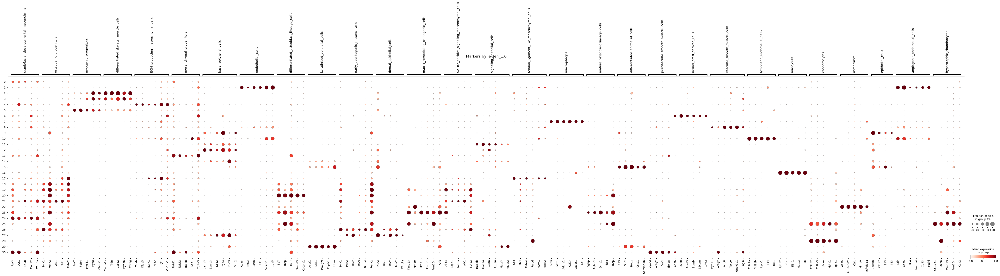

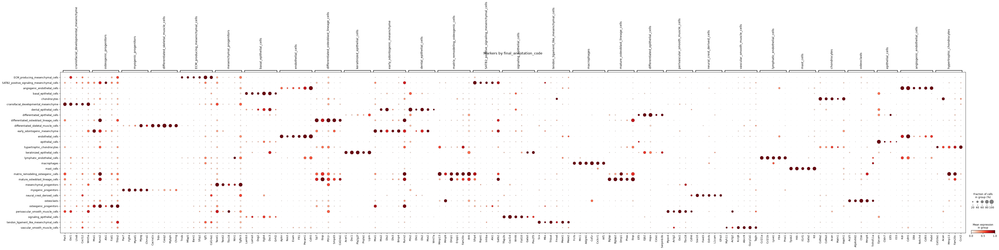

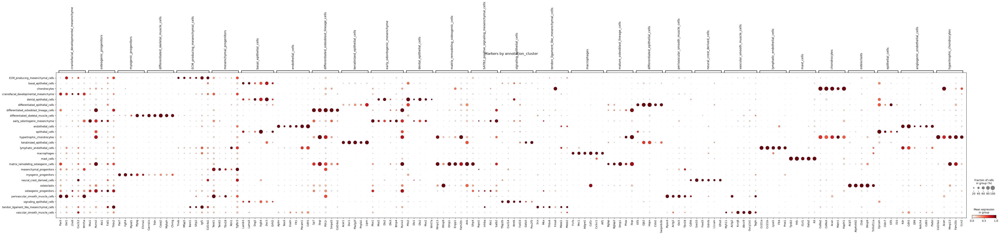

In [11]:
for grp in ['leiden_1.0', 'final_annotation_code', 'annotation_cluster']:
    sc.pl.dotplot(adata, markers, groupby=grp, layer='lognorm', use_raw=False,
                  standard_scale='var', dendrogram=False, title=f'Markers by {grp}')

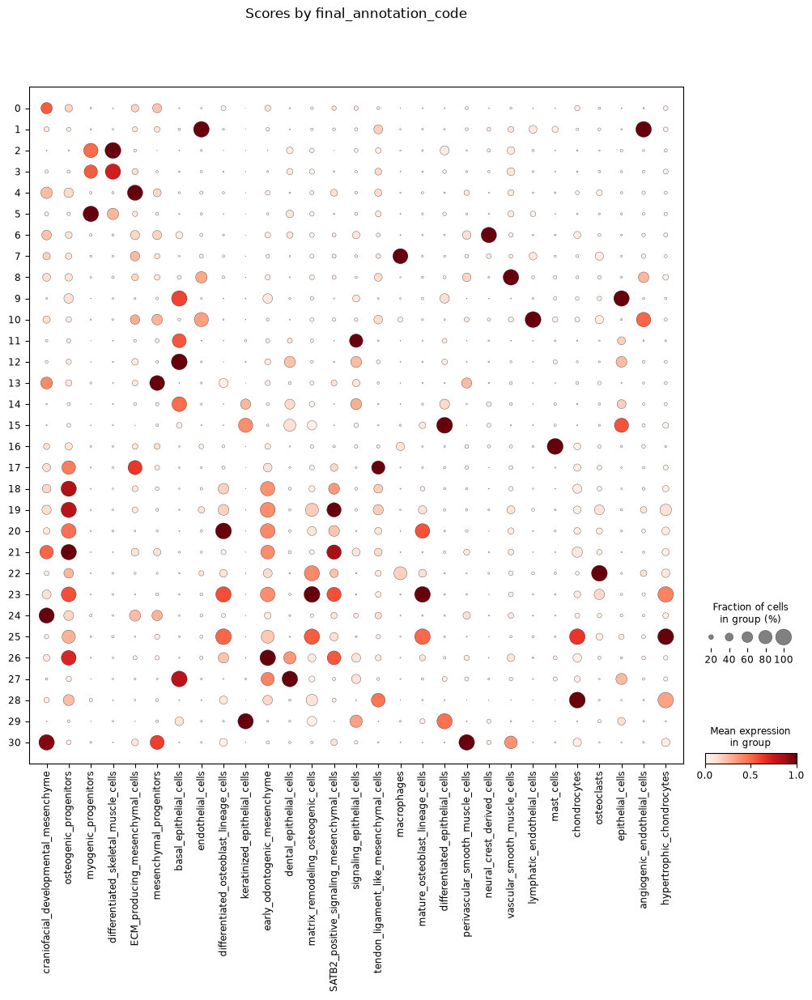

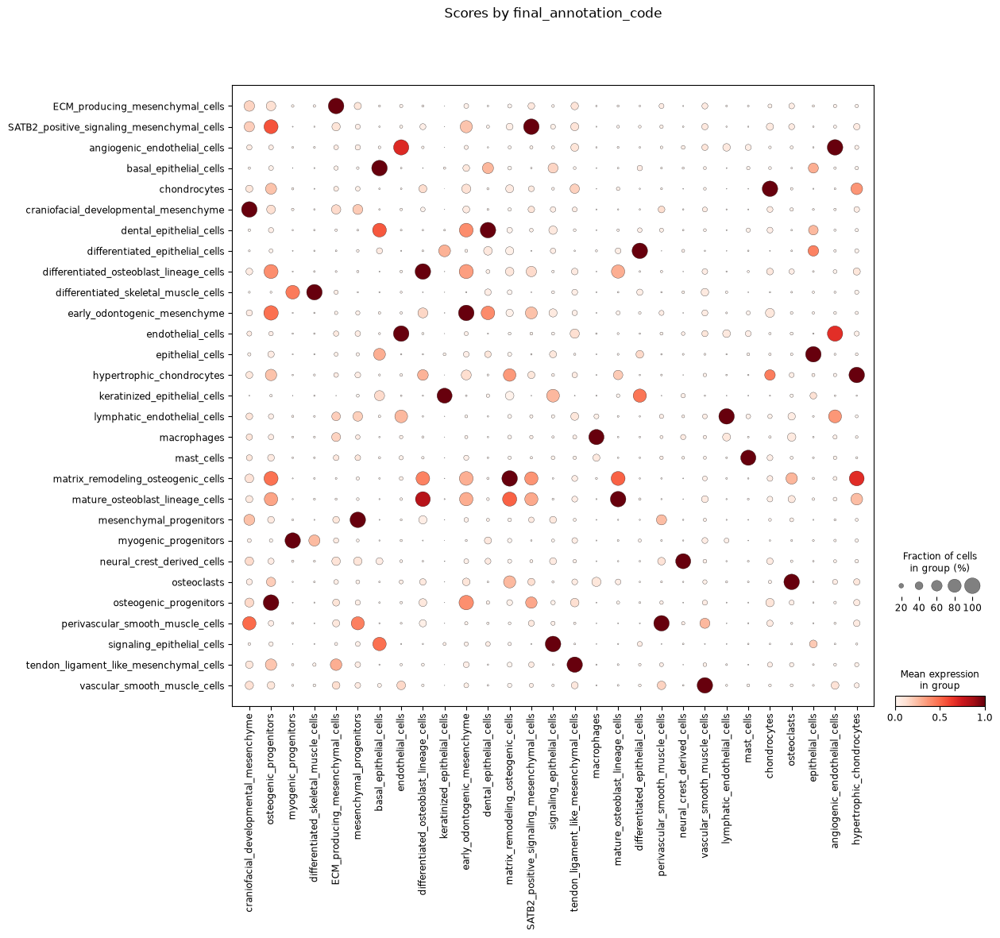

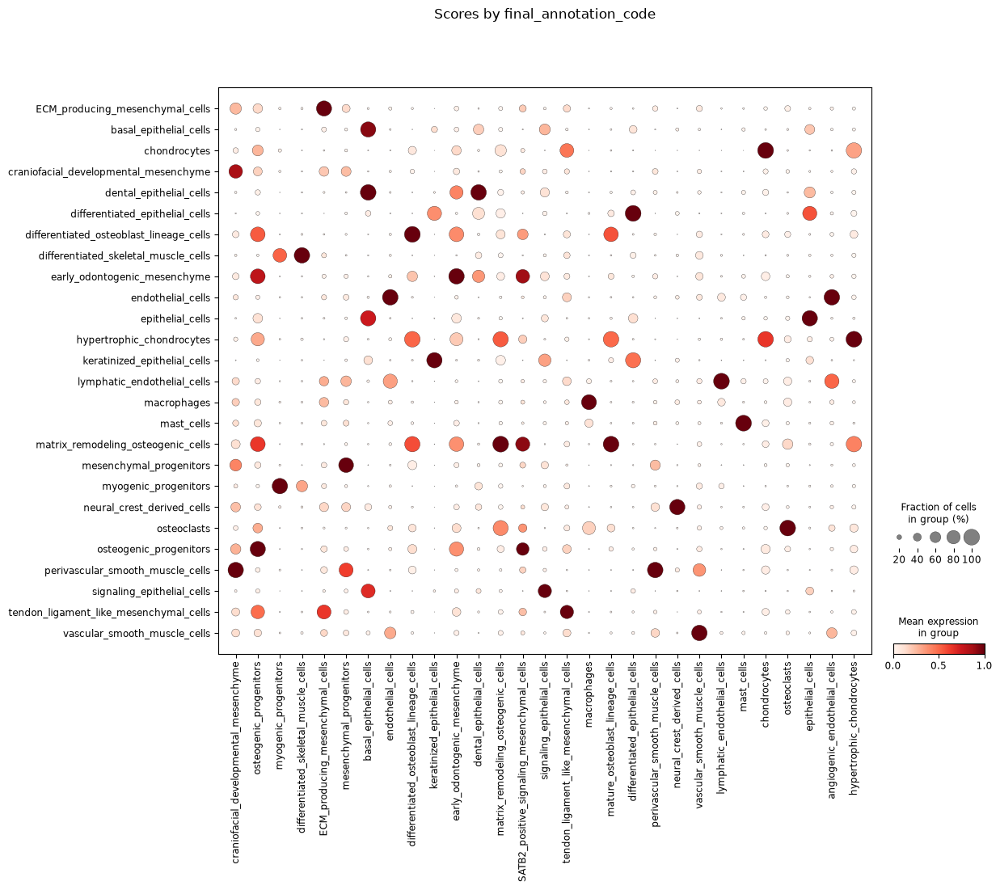

In [12]:
# --- dotplot of scores by final_annotation_code ---
sa = sc.AnnData(adata.obs[score_cols].clip(lower=0).values.astype(np.float32),
                obs=adata.obs[['leiden_1.0', 'final_annotation_code', 'annotation_cluster']].copy())
sa.var_names = [c.replace('score_', '') for c in score_cols]
sc.pl.dotplot(sa, list(sa.var_names), groupby='leiden_1.0',
              standard_scale='var', dendrogram=False, title='Scores by final_annotation_code')

sc.pl.dotplot(sa, list(sa.var_names), groupby='final_annotation_code',
              standard_scale='var', dendrogram=False, title='Scores by final_annotation_code')

sc.pl.dotplot(sa, list(sa.var_names), groupby='annotation_cluster',
              standard_scale='var', dendrogram=False, title='Scores by final_annotation_code')

In [111]:
# adata.write_h5ad(OUTPUT_DIR / "adata_annot.h5ad")
adata = sc.read_h5ad(OUTPUT_DIR / "adata_annot.h5ad")

In [116]:
adata.obs

,cell,original_cell_id,centroid_x,centroid_y,centroid_z,component,volume,surface_area,scale,region,...,score_vascular_smooth_muscle_cells,score_lymphatic_endothelial_cells,score_mast_cells,score_chondrocytes,score_osteoclasts,score_epithelial_cells,score_angiogenic_endothelial_cells,score_hypertrophic_chondrocytes,final_annotation_code,annotation_cluster
0,0,mgdkkhbg-1,8149.490234,14836.105469,0.381579,6,19.00,166.0,1.0,cell_boundaries,...,-0.053350,-0.019341,-0.019341,-0.038485,-0.048605,0.000000,-0.064149,-0.051772,ECM_producing_mesenchymal_cells,craniofacial_developmental_mesenchyme
1,1,mgdnbnlh-1,8146.351562,14844.744141,0.483033,9,90.25,444.0,1.0,cell_boundaries,...,0.098991,-0.117304,0.366226,-0.275296,0.301081,-0.334641,1.590129,-0.256979,endothelial_cells,endothelial_cells
2,2,mgkecjig-1,8207.224609,14784.737305,0.474222,9,64.25,378.0,1.0,cell_boundaries,...,-0.274194,-0.100185,-0.069327,-0.329803,-0.109582,-0.123544,-0.362890,-0.340016,differentiated_skeletal_muscle_cells,differentiated_skeletal_muscle_cells
3,3,ohbdhbpo-1,8214.446289,14777.537109,0.492537,9,33.50,262.0,1.0,cell_boundaries,...,-0.120946,-0.049047,-0.032698,-0.097596,0.559035,-0.160717,-0.158403,-0.150375,mesenchymal_progenitors,differentiated_skeletal_muscle_cells
5,5,mgcegjnc-1,8178.070312,14816.170898,0.483889,6,56.25,346.0,1.0,cell_boundaries,...,-0.106971,-0.092539,-0.027637,-0.075435,-0.116820,-0.128101,-0.158196,-0.115458,mesenchymal_progenitors,ECM_producing_mesenchymal_cells
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26050,26050,fiacpghk-1,4645.688965,22404.675781,0.646490,2,87.25,438.0,1.0,cell_boundaries,...,-0.166374,-0.214993,-0.361044,-0.321695,-0.371633,0.623889,-0.322437,-0.376189,differentiated_epithelial_cells,keratinized_epithelial_cells
26051,26051,fiaadkjj-1,4638.232422,22420.203125,0.497308,2,81.25,416.0,1.0,cell_boundaries,...,-0.302622,-0.300255,-0.332816,-0.309766,-0.396606,-0.307594,-0.331745,-0.331077,keratinized_epithelial_cells,keratinized_epithelial_cells
26052,26052,fiaadhgh-1,4645.461914,22422.109375,0.800287,2,43.50,234.0,1.0,cell_boundaries,...,-0.248166,-0.244417,-0.282792,-0.307368,-0.342228,0.471609,-0.407467,-0.358913,differentiated_epithelial_cells,keratinized_epithelial_cells
26053,26053,nielkhcf-1,4651.107910,22395.664062,0.509211,2,23.75,228.0,1.0,cell_boundaries,...,-0.235827,-0.171906,-0.186312,-0.300507,-0.319662,-0.241573,-0.280416,-0.359285,keratinized_epithelial_cells,keratinized_epithelial_cells


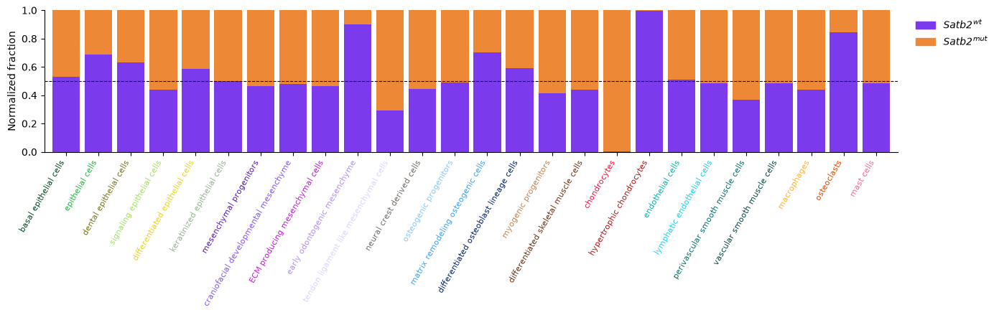

In [121]:
import pandas as pd
import matplotlib.pyplot as plt

cluster_key = "annotation_cluster"
cond_key = "condition"   # "+/+" / "-/-"

ct = pd.crosstab(adata.obs[cluster_key], adata.obs[cond_key])
order = [t for t in L2_COLORS if t in ct.index] + [t for t in ct.index if t not in L2_COLORS]
ct = ct.loc[order, ["wt", "mut"]]

# normalize to total cells per condition, then to 1 within each cluster
norm = ct.div(ct.sum(axis=0), axis=1)
norm = norm.div(norm.sum(axis=1), axis=0)

colors = {"wt": "#7C3AED", "mut": "#ED8936"}
labels = {"wt": r"$\it{Satb2}^{wt}$", "mut": r"$\it{Satb2}^{mut}$"}

fig, ax = plt.subplots(figsize=(14, 4.5))
norm.plot(kind="bar", stacked=True, ax=ax, width=0.85,
          color=[colors[c] for c in norm.columns], legend=False)

ax.axhline(0.5, color="black", lw=0.8, ls="--")
ax.set_ylim(0, 1)
ax.set_ylabel("Normalized fraction")


for s in ["top", "right"]:
    ax.spines[s].set_visible(False)

handles = [plt.Rectangle((0, 0), 1, 1, color=colors[c]) for c in norm.columns]
ax.legend(handles, [labels[c] for c in norm.columns],
          frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_xlabel("")
ax.set_xticklabels([t.replace("_", " ") for t in norm.index], rotation=60, ha="right", fontsize=8)
for lab in ax.get_xticklabels():
    lab.set_color(L2_COLORS.get(lab.get_text().replace(" ", "_"), "k"))
fig.tight_layout()
plt.show()

In [ ]:
import pandas as pd, matplotlib.pyplot as plt, scanpy as sc

from utils.utils import PALETTE, LEVEL1_COLORS, L2_COLORS
from utils.functions import apply_palette, show_palette


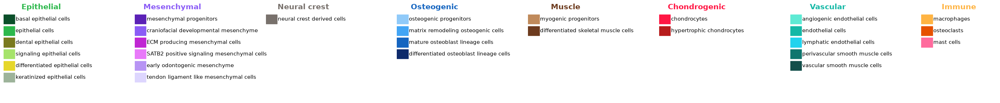

In [48]:
def show_palette():
    fig, axes = plt.subplots(1, len(PALETTE), figsize=(3.5* len(PALETTE), 3))
    for ax, (g, d) in zip(axes, PALETTE.items()):
        ax.set_title(g, color=LEVEL1_COLORS[g], weight='bold', fontsize=15)
        for i, (t, c) in enumerate(d.items()):
            ax.add_patch(plt.Rectangle((0, -i), .15, .8, color=c))
            ax.text(.16, -i + .4, t.replace('_', ' '), va='center', fontsize=11)
        ax.set_xlim(0, 1); ax.set_ylim(-6.5, 1); ax.axis('off')
    plt.tight_layout(); plt.show()
show_palette()

In [51]:
# apply_palette(adata)
# show_palette()
# with plt.rc_context({'figure.figsize': (4, 6)}):   # (width, height) in inches, per panel
#     sc.pl.embedding(adata[adata.obs['sample'] == 'wt_1'], basis='spatial', color=['final_annotation_code', 'annotation_cluster'],
#                     s=10, frameon=False, legend_loc=None)

Connect adata to sdata

In [17]:
from spatialdata.models import TableModel

In [18]:
samples = [f'{g}_{i}' for g in ['wt', 'mut'] for i in range(1, 5)]
sdatas = {s: globals()[s] for s in samples}      # or: {s: sd.read_zarr(path) for s, path in paths.items()}

def link_table(sdata, ad_s, id_col='cell', shapes='cell_boundaries', name='table_annot'):
    shp = sdata[shapes]
    ad = ad_s.copy()
    ad.uns.pop('spatialdata_attrs', None)
    ad.obs['region_sd'] = pd.Categorical([shapes] * ad.n_obs)
    ad.obs['instance_id'] = ad.obs[id_col].astype(shp.index.dtype).values
    ids = ad.obs['instance_id']
    c = shp.loc[ids[ids.isin(shp.index)].values].geometry.centroid
    m = ids.isin(shp.index).values
    d = np.hypot(c.x.values - ad.obs['centroid_x'].values[m], c.y.values - ad.obs['centroid_y'].values[m])
    sdata[name] = TableModel.parse(ad, region=shapes, region_key='region_sd', instance_key='instance_id')
    return dict(n_cells=ad.n_obs, n_shapes=len(shp), unique=ids.is_unique,
                matched=round(m.mean(), 4), median_dist=round(float(np.median(d)), 3))

report = pd.DataFrame({s: link_table(sdatas[s], adata[adata.obs['sample'] == s]) for s in samples}).T
report

,n_cells,n_shapes,unique,matched,median_dist
wt_1,26871,27343,True,1.0,0.3
wt_2,24828,25154,True,1.0,0.345
wt_3,22654,23387,True,1.0,0.295
wt_4,30322,31126,True,1.0,0.311
mut_1,21469,21960,True,1.0,0.315
mut_2,23470,24114,True,1.0,0.295
mut_3,25948,26634,True,1.0,0.323
mut_4,25163,26055,True,1.0,0.322


In [25]:
tbl = sdatas['wt_1']['table_annot']                                     # the linked table
groups = [t for t in L2_COLORS if t in set(tbl.obs['final_annotation_code'])]
palette = [L2_COLORS[t] for t in groups]

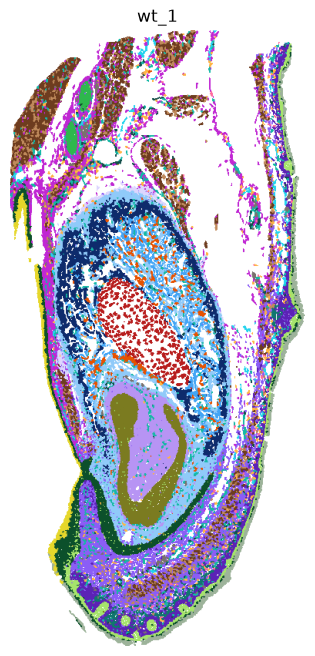

In [26]:
fig, ax = plt.subplots(figsize=(6, 8))
sdatas['wt_1'].pl.render_shapes('cell_boundaries', color='annotation_cluster', table_name='table_annot',
                      groups=groups, palette=palette).pl.show(ax=ax)
if ax.get_legend(): 
    ax.get_legend().remove()
ax.set_axis_off()
ax.title.set_text('wt_1')
plt.show()

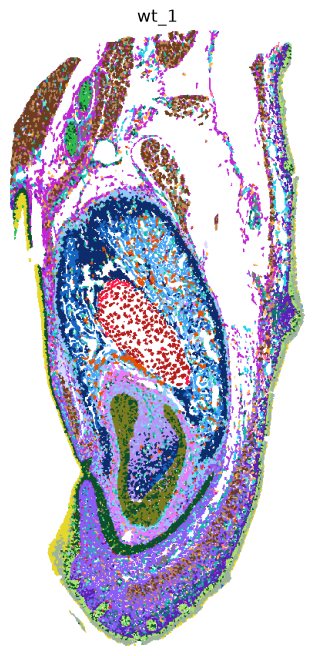

In [23]:
fig, ax = plt.subplots(figsize=(6, 8))
sdatas['wt_1'].pl.render_shapes('cell_boundaries', color='final_annotation_code', table_name='table_annot').pl.show(ax=ax)
if ax.get_legend(): 
    ax.get_legend().remove()
ax.set_axis_off()
ax.title.set_text('wt_1')
plt.show()

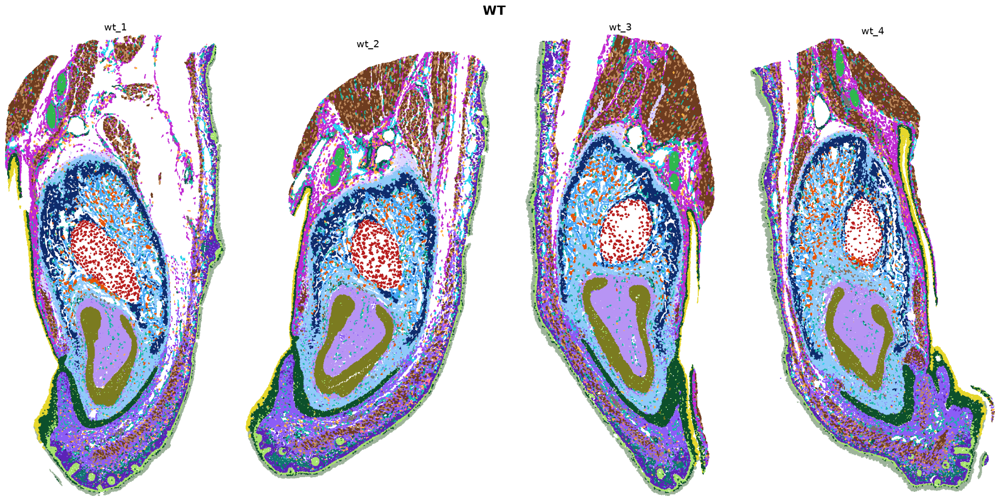

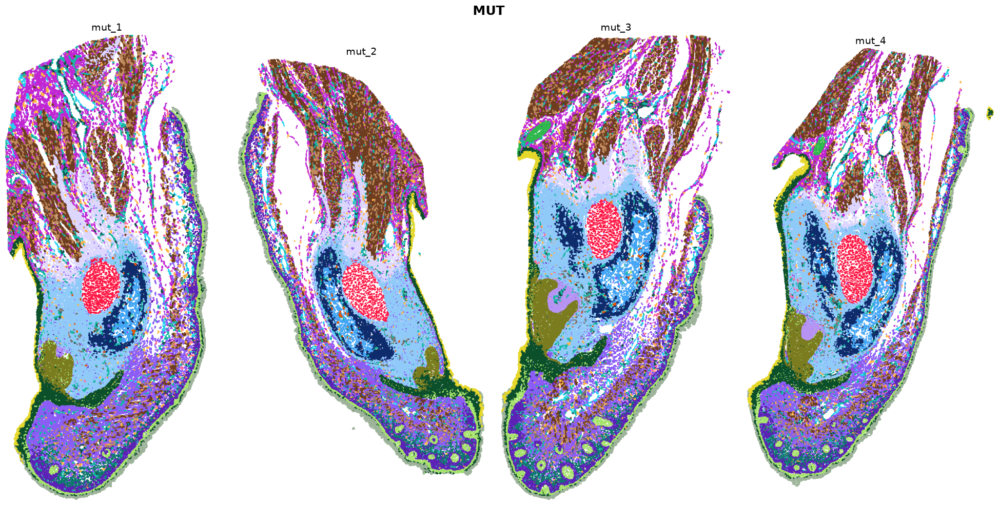

In [20]:
groups = [t for t in L2_COLORS if t in set(adata.obs['annotation_cluster'])]
palette = [L2_COLORS[t] for t in groups]

for cond in ['wt', 'mut']:
    fig, axes = plt.subplots(1, 4, figsize=(20, 10))
    for ax, i in zip(axes, range(1, 5)):
        s = f'{cond}_{i}'
        sdatas[s].pl.render_shapes('cell_boundaries', color='annotation_cluster', table_name='table_annot',
                                   groups=groups, palette=palette).pl.show(ax=ax)
        if ax.get_legend(): ax.get_legend().remove()
        ax.set_axis_off()
        ax.set_title(s, fontsize=14)
    fig.suptitle(cond.upper(), fontsize=18, weight='bold')
    plt.tight_layout(); plt.show()

In [52]:
adata.write_h5ad(OUTPUT_DIR / "adata_annotated.h5ad")

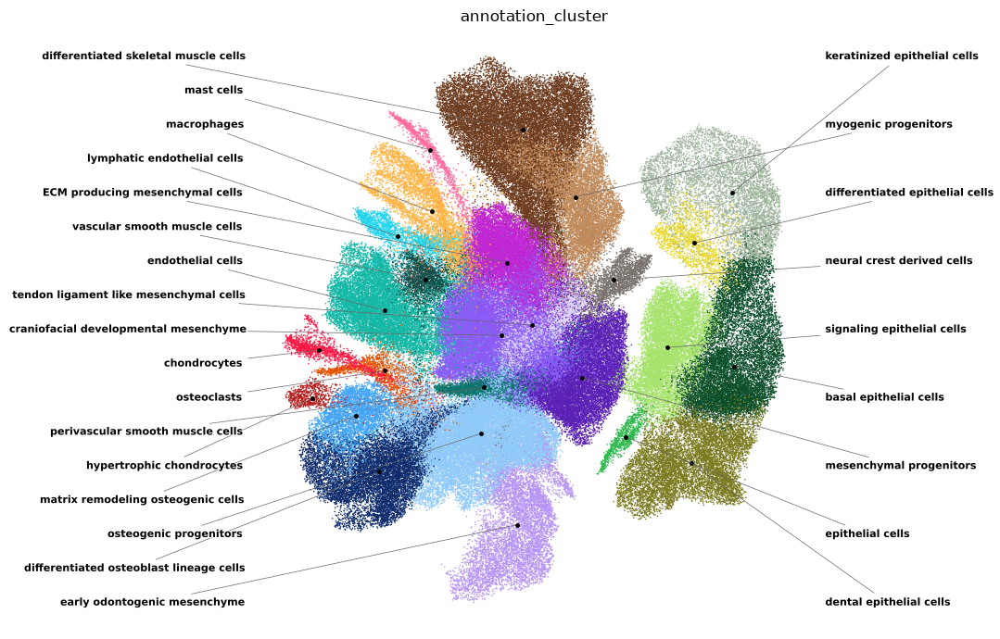

In [104]:
import matplotlib.patheffects as pe

key = 'annotation_cluster'
cats = adata.obs[key].cat.categories
fig, ax = plt.subplots(figsize=(11, 7))
sc.pl.umap(adata, color=key, size=5, frameon=False, legend_loc=None, show=False, ax=ax,
           palette=[L2_COLORS[t] for t in cats])

xy = pd.DataFrame(adata.obsm['X_umap'], columns=['x', 'y'], index=adata.obs_names)
cent = xy.groupby(adata.obs[key], observed=True).median()
(x0, y0), (x1, y1) = xy.min(), xy.max()
xmid, pad = (x0 + x1) / 2, 0.08 * (x1 - x0)

for side, sub in cent.groupby(cent.x >= xmid):
    sub = sub.sort_values('y')
    ys = np.linspace(y0, y1, len(sub)) if len(sub) > 1 else [sub.y.iloc[0]]
    lx, ha = (x1 + pad, 'left') if side else (x0 - pad, 'right')
    for (t, r), ly in zip(sub.iterrows(), ys):
        ax.annotate(t.replace('_', ' '), xy=(r.x, r.y), xytext=(lx, ly), ha=ha, va='center',
                    fontsize=8, weight='bold', 
                    # color=L2_COLORS.get(t, 'k'),
                    path_effects=[pe.withStroke(linewidth=1.5, foreground='w')],
                    arrowprops=dict(arrowstyle='-', color='0.4', lw=0.5,
                                    connectionstyle='angle,angleA=0,angleB=90,rad=0' if False else 'arc3'))
        ax.plot(r.x, r.y, 'o', ms=2.5, color='k')          # anchor dot at cluster center

ax.set_xlim(x0 - 4 * pad, x1 + 4 * pad)
ax.set_title(key); plt.tight_layout(); plt.show()

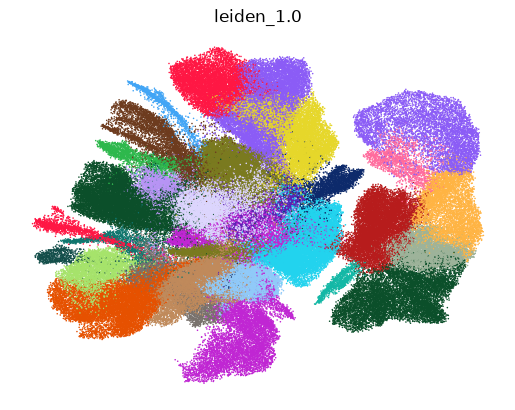

In [106]:
sc.pl.umap(adata, color=["leiden_1.0"], size=5, frameon=False, legend_loc=None, show=True)